In [1]:
# Part A 
import math 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay 
from sklearn.preprocessing import StandardScaler 

# Part B 

df = sns.load_dataset('titanic')
print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


#### Feature Analysis 

* **Useful Features:**
    * **pclass (Passenger Class):** Socio-economic status often correlated with survival priority.
    * **sex:** "Women and children first" was a known protocol during the sinking.
    * **age:** Younger passengers often had higher survival rates.
    * **fare:** Correlates with class and cabin location.
    * **embarked:** Port of origin might show some correlation based on cabin assignments.

* **Features to Exclude/Handle Carefully:**
    * **deck:** Very sparse (high missing values).
    * **embark_town:** Redundant if 'embarked' is used.
    * **alive:** This is a direct proxy for the target 'survived' (Target Leakage).
    * **who/adult_male:** Redundant info already captured by 'age' and 'sex'.

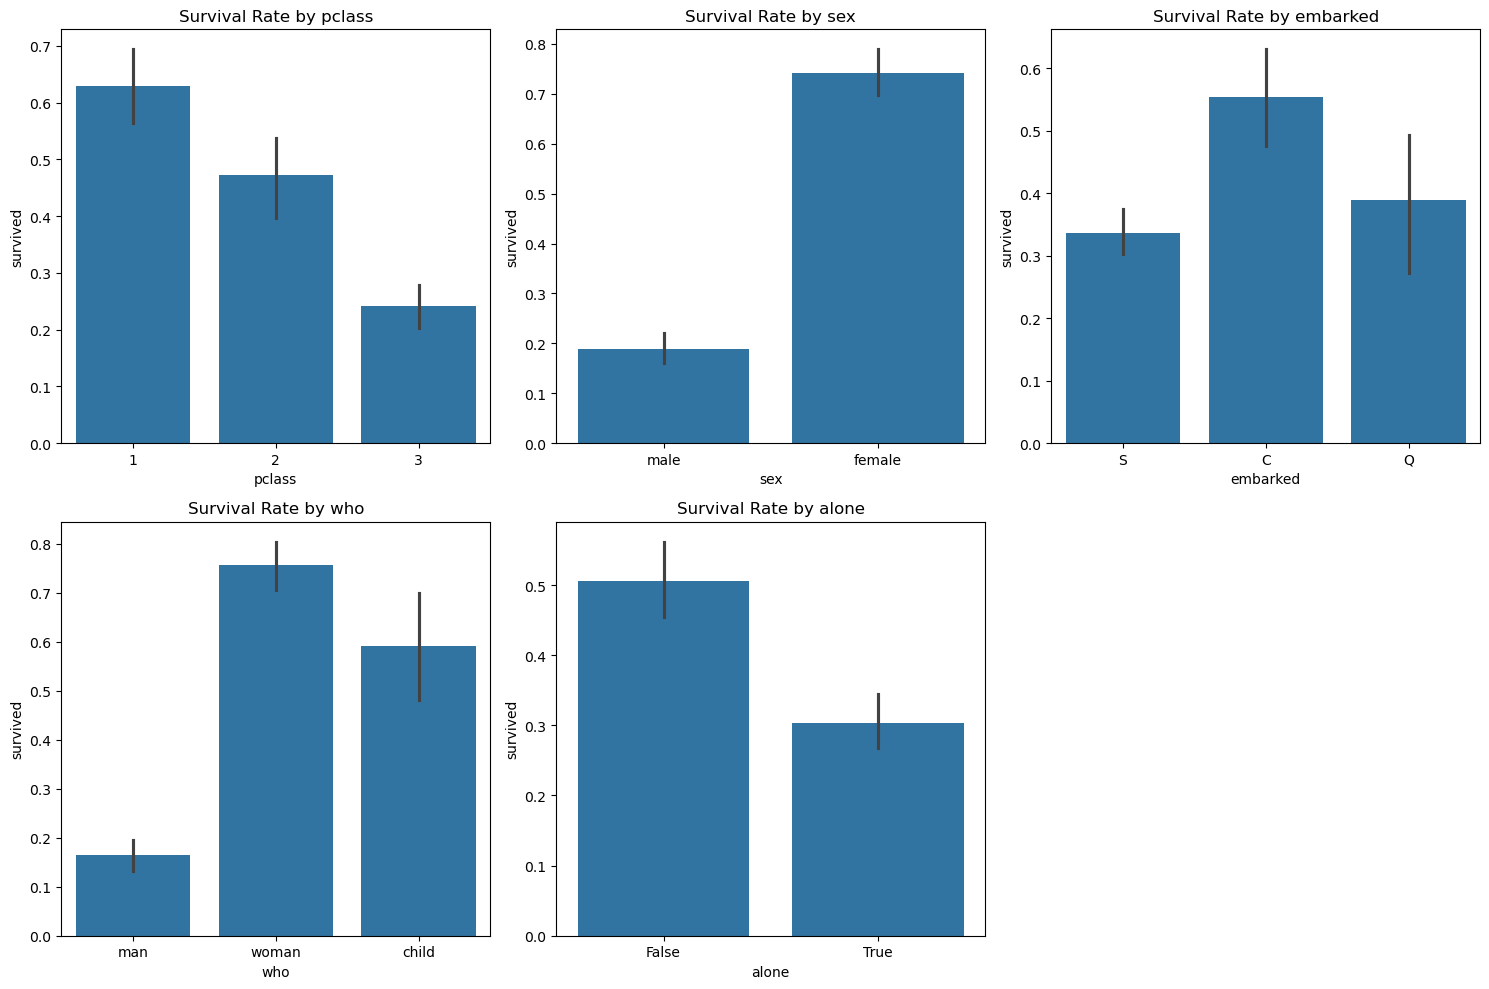

In [2]:
# Part C.1

categorical_cols = ['pclass', 'sex', 'embarked', 'who', 'alone']

plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    sns.barplot(x=col, y='survived', data=df)
    plt.title(f'Survival Rate by {col}')

plt.tight_layout()
plt.show()

In [3]:
# Part C.2:

# Dropping 'alive' (target leakage), 'deck' (too many missing values), 
# and redundant columns like 'embark_town', 'who', 'adult_male'
cols_to_drop = ['alive', 'deck', 'embark_town', 'who', 'adult_male', 'class']
df_cleaned = df.drop(columns=cols_to_drop)

# Handling Missing Values 
df_cleaned['age'] = df_cleaned['age'].fillna(df_cleaned['age'].median())
df_cleaned['embarked'] = df_cleaned['embarked'].fillna(df_cleaned['embarked'].mode()[0])

df_encoded = pd.get_dummies(df_cleaned, columns=['sex', 'embarked'], drop_first=True)

X = df_encoded.drop('survived', axis=1)
y = df_encoded['survived']

print(f"Feature Matrix X Shape: {X.shape}")
print(f"Target Vector y Shape: {y.shape}")
display(X.head())

Feature Matrix X Shape: (891, 9)
Target Vector y Shape: (891,)


,pclass,age,sibsp,parch,fare,alone,sex_male,embarked_Q,embarked_S
0,3,22.0,1,0,7.2500,False,True,False,True
1,1,38.0,1,0,71.2833,False,False,False,False
2,3,26.0,0,0,7.9250,True,False,False,True
3,1,35.0,1,0,53.1000,False,False,False,True
4,3,35.0,0,0,8.0500,True,True,False,True


Justification: I dropped alive to avoid target leakage, and deck due to excessive missing values. I filled missing age values with the median to maintain data integrity without being skewed by outliers. Categorical features like sex and embarked were one-hot encoded to make them mathematically usable for the tree.

In [4]:
# Part D 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")


print("\n--- Class Balance (Proportion of Survived vs Died) ---")
print(f"Training set:\n{y_train.value_counts(normalize=True)}")
print(f"\nTest set:\n{y_test.value_counts(normalize=True)}")

Training features shape: (712, 9)
Testing features shape: (179, 9)
Training target shape: (712,)
Testing target shape: (179,)

--- Class Balance (Proportion of Survived vs Died) ---
Training set:
survived
0    0.623596
1    0.376404
Name: proportion, dtype: float64

Test set:
survived
0    0.586592
1    0.413408
Name: proportion, dtype: float64


In [6]:
# Part F

import numpy as np

class Node:
    def __init__(self, left=None, right=None, feature=None, threshold=None, classifier=None):
       
        self.left = left 
        self.right = right 
        self.feature = feature 
        self.threshold = threshold 
        
        self.classifier = classifier 

    def is_leaf(self):
        return self.classifier is not None

class DecisionTree:
    def __init__(self, max_depth=5, min_samples_split=5):
        self.max_depth = max_depth 
        self.min_samples = min_samples_split 
        self.root = None 

    def _gini_of_data(self, Xy):
      
        # no data, so return 0
        if len(Xy) == 0:
            return 0
        
        labels = Xy[:, -1]
        
        _, counts = np.unique(labels, return_counts=True)
        
        probabilities = counts / len(labels)
        
        # Gini = 1 - sum(p^2)
        gini = 1 - np.sum(probabilities**2)
        return gini

    def information_gain(self, parent_H, left, right):
        
        #IG = parent Gini minus weighted child Gini.
        
        n_total = len(left) + len(right)
        n_left = len(left)
        n_right = len(right)
        
        if n_total == 0:
            return 0
            
        gini_left = self._gini_of_data(left)
        gini_right = self._gini_of_data(right)
        
        weighted_child_gini = (n_left / n_total) * gini_left + (n_right / n_total) * gini_right
        
        ig = parent_H - weighted_child_gini
        return ig

    def _best_split(self, Xy):
        """
        Search candidate thresholds per feature and return the best information gain. 
        """
        best_gain = -1
        split_idx, split_thresh = None, None
        
        n_features = Xy.shape[1] - 1
        parent_gini = self._gini_of_data(Xy)
        
        for feat_idx in range(n_features):
            feature_values = Xy[:, feat_idx]
            thresholds = np.unique(feature_values)
            
            for threshold in thresholds:
                left_mask = Xy[:, feat_idx] <= threshold
                left = Xy[left_mask]
                right = Xy[~left_mask]
                
                if len(left) > 0 and len(right) > 0:
                    gain = self.information_gain(parent_gini, left, right)
                    
                    if gain > best_gain:
                        best_gain = gain
                        split_idx = feat_idx
                        split_thresh = threshold
                        
        return split_idx, split_thresh, best_gain

    def _make_tree(self, Xy, depth=0):
        
        n_samples, n_features = Xy.shape[0], Xy.shape[1] - 1

        # Checking stopping conditions
        if depth >= self.max_depth or n_samples < self.min_samples or len(np.unique(Xy[:, -1])) == 1:
            # Creating leaf node
            common_class = self._most_common_label(Xy[:, -1])
            return Node(classifier=common_class)
        
        idx, thresh, gain = self._best_split(Xy)
        
        if gain <= 0:
            common_class = self._most_common_label(Xy[:, -1])
            return Node(classifier=common_class)
            
        # Branches part
        left_mask = Xy[:, idx] <= thresh
        left_child = self._make_tree(Xy[left_mask], depth + 1)
        right_child = self._make_tree(Xy[~left_mask], depth + 1)
        
        return Node(left=left_child, right=right_child, feature=idx, threshold=thresh)

    def _most_common_label(self, y):
        """Helper to find the majority class (0 or 1) in a leaf."""
        vals, counts = np.unique(y, return_counts=True)
        return vals[np.argmax(counts)]

    def fit(self, X, y):
        dataset = np.concatenate((X.to_numpy(), y.to_numpy().reshape(-1, 1)), axis=1)
        self.root = self._make_tree(dataset)

    def predict(self, X):
        
        X_data = X.to_numpy()
        return np.array([self._predict_single(sample, self.root) for sample in X_data])

    def _predict_single(self, x, node):
        """
        Traverses the tree for a single data point.
        """
        if node.is_leaf():
            return node.classifier
        
        if x[node.feature] <= node.threshold:
            return self._predict_single(x, node.left)
        else:
            return self._predict_single(x, node.right)

    

Accuracy: 0.7989
F1 Score: 0.7391

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



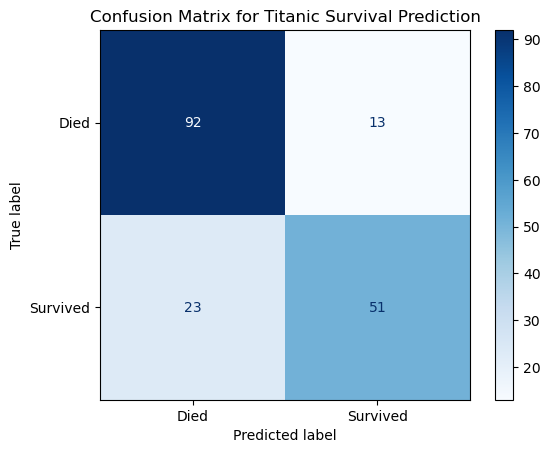

In [7]:
# Part G - Evaluation

my_tree = DecisionTree(max_depth=3, min_samples_split=5)
my_tree.fit(X_train, y_train)

y_pred = my_tree.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died', 'Survived'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Titanic Survival Prediction")
plt.show()

**Assume your model gives an Accuracy of ∼60%. What is the most probable explanation?**

If a model achieves approximately 60% accuracy on this dataset, it is likely a Majority Class Classifier. In mytraining set, about 60% of the passengers died (class 0). If the model failed to learn any real patterns (perhaps due to poor feature selection or a max_depth that is too small), it might simply predict that everyone died. By always guessing "Died," it would naturally be correct about 60% of the time, even though it hasn't actually "learned" anything.



In [9]:
# Investigating the 60% explanation
majority_guess = np.zeros_like(y_test)
baseline_accuracy = accuracy_score(y_test, majority_guess)
print(f"Baseline Accuracy (always guessing 'Died'): {baseline_accuracy:.4f}")

Baseline Accuracy (always guessing 'Died'): 0.5866


**Suggested Hyperparameter**: max_depth 

This controls how complex the tree can get. If the depth is too low (e.g., 1 or 2), the model is too simple (underfitting) and misses important rules like the combination of "Age" and "Class." If it's too high, the model might memorize the training data (overfitting) and perform poorly on new test data. 

Depth 1: Accuracy = 0.7821
Depth 2: Accuracy = 0.7654
Depth 3: Accuracy = 0.7989
Depth 4: Accuracy = 0.7989
Depth 5: Accuracy = 0.7989
Depth 6: Accuracy = 0.7989
Depth 7: Accuracy = 0.8101
Depth 8: Accuracy = 0.8045
Depth 9: Accuracy = 0.8045
Depth 10: Accuracy = 0.7821


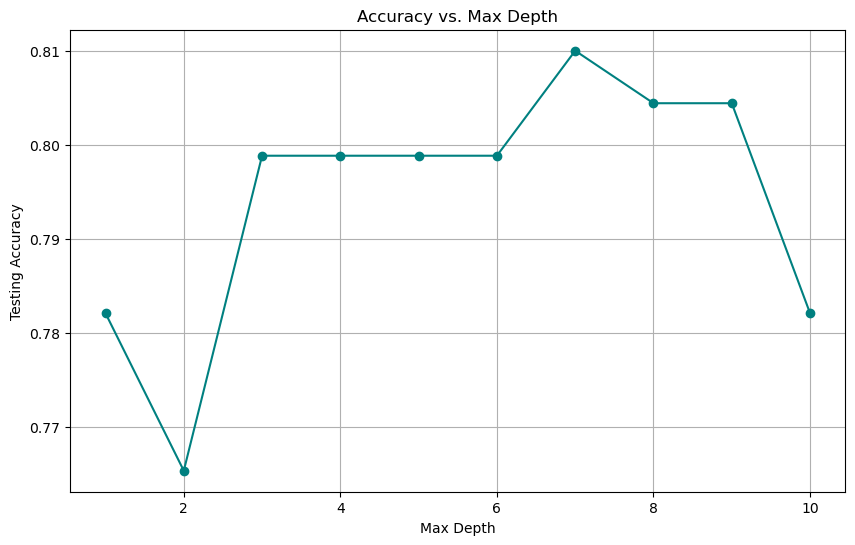

In [10]:
# Part H 

depths = range(1, 11)
accuracies = []

for d in depths:
    dt = DecisionTree(max_depth=d, min_samples_split=5)
    dt.fit(X_train, y_train)
    
    preds = dt.predict(X_test)
    acc = accuracy_score(y_test, preds)
    accuracies.append(acc)
    print(f"Depth {d}: Accuracy = {acc:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(depths, accuracies, marker='o', color='teal')
plt.title("Accuracy vs. Max Depth")
plt.xlabel("Max Depth")
plt.ylabel("Testing Accuracy")
plt.grid(True)
plt.show()

### Identifying the Best Value 

From the output above, the **best value** for `max_depth` is **7**, achieving an accuracy of **0.8101**. At this depth, the tree has enough "room" to learn the complex relationships in the Titanic data (like how age affects survival differently for different classes) without becoming so specific that it loses its ability to generalize.


### Analyzing the Trend

The trend observed is a textbook example of the **Bias-Variance Tradeoff**:

* **Underfitting (Low Depth 1-2):** Initially, the accuracy is lower because the tree is too simple. It doesn't have enough branches to capture the nuances of the data, leading to high bias.
* **The Sweet Spot (Depth 3-7):** Accuracy improves and then stabilizes. Between depths 3 and 6, the model is very consistent, and at depth 7, it finds the optimal balance between learning patterns and staying general enough for new data.
* **Overfitting (High Depth 8-10):** Accuracy starts to drop after depth 7. This is because the tree is becoming too deep and complex. It is starting to "memorize" the specific noise and quirks of the 712 passengers in the training set rather than learning broad survival rules. Consequently, its performance on the testing set (unseen data) begins to suffer.